In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('heart_statlog_cleveland_hungary_final.csv')

In [ ]:
data["target"].value_counts()

target
1    629
0    561
Name: count, dtype: int64

In [ ]:
x_norm=data.drop(['target'],axis=1)
y=data['target']

In [ ]:
x_norm


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope
0,40,1,2,140,289,0,0,172,0,0.0,1
1,49,0,3,160,180,0,0,156,0,1.0,2
2,37,1,2,130,283,0,1,98,0,0.0,1
3,48,0,4,138,214,0,0,108,1,1.5,2
4,54,1,3,150,195,0,0,122,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2
1186,68,1,4,144,193,1,0,141,0,3.4,2
1187,57,1,4,130,131,0,0,115,1,1.2,2
1188,57,0,2,130,236,0,2,174,0,0.0,2


In [ ]:

#scale data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x_norm)

x

array([[-1.46672783,  0.55599543, -1.31835093, ..., -0.79521891,
        -0.84979236, -1.02321701],
       [-0.50460037, -1.79857595, -0.24893198, ..., -0.79521891,
         0.07111913,  0.61558278],
       [-1.78743698,  0.55599543, -1.31835093, ..., -0.79521891,
        -0.84979236, -1.02321701],
       ...,
       [ 0.35062404,  0.55599543,  0.82048698, ...,  1.25751537,
         0.25530143,  0.61558278],
       [ 0.35062404, -1.79857595, -1.31835093, ..., -0.79521891,
        -0.84979236,  0.61558278],
       [-1.68053393,  0.55599543, -0.24893198, ..., -0.79521891,
        -0.84979236, -1.02321701]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
nb=GaussianNB()
nb


GaussianNB()

In [ ]:
nb.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_pred_nb=nb.predict(x_test)
print(classification_report(y_test,y_pred_nb))


              precision    recall  f1-score   support

           0       0.85      0.83      0.84       107
           1       0.86      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.85      0.86       238
weighted avg       0.86      0.86      0.86       238



In [ ]:

from sklearn.metrics import accuracy_score,confusion_matrix
acc_gnb=accuracy_score(y_test,y_pred_nb)*100
print("Accuracy=",acc_gnb)


Accuracy= 85.71428571428571


Text(50.722222222222214, 0.5, 'Actual')

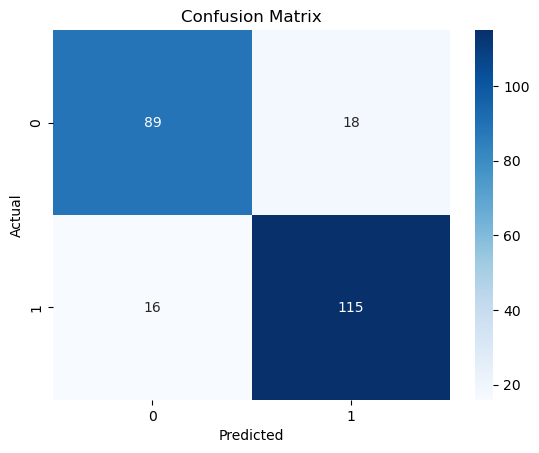

In [ ]:
nb_cm=confusion_matrix(y_test,y_pred_nb)
sns.heatmap(nb_cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.85      0.84      0.85       107
           1       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



Accuracy= 86.1344537815126


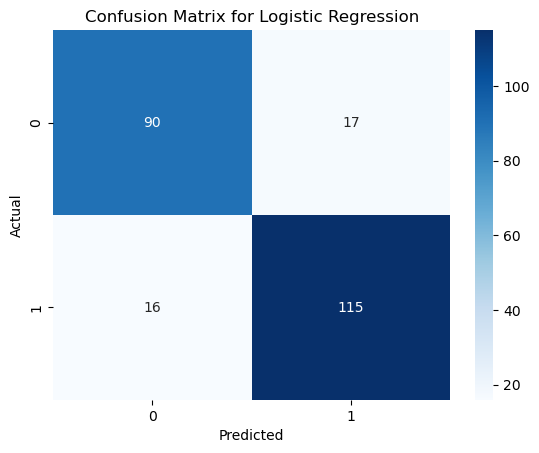

In [ ]:

acc_lr = accuracy_score(y_test, y_pred_lr) * 100
print("Accuracy=",acc_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Decision Tree classifier

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)


DecisionTreeClassifier()

In [ ]:
# Make predictions on the test set
y_pred_dt = dt.predict(x_test)
# Evaluate the model
print(classification_report(y_test, y_pred_dt))

acc_dt = accuracy_score(y_test, y_pred_dt) * 100
print("Accuracy=", acc_dt)


              precision    recall  f1-score   support

           0       0.84      0.92      0.88       107
           1       0.93      0.85      0.89       131

    accuracy                           0.88       238
   macro avg       0.88      0.89      0.88       238
weighted avg       0.89      0.88      0.88       238

Accuracy= 88.23529411764706


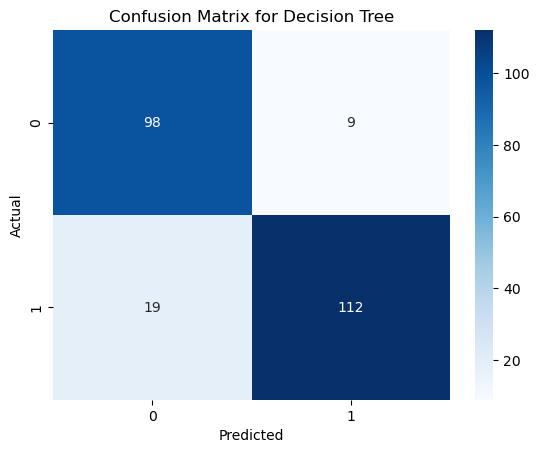

In [ ]:
dt_cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
#KNN classifier

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5) # You can adjust the number of neighbors
knn.fit(x_train, y_train)


KNeighborsClassifier()

In [ ]:
# Make predictions on the test set
y_pred_knn = knn.predict(x_test)


In [ ]:
# Evaluate the model
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.91      0.83      0.87       107
           1       0.87      0.93      0.90       131

    accuracy                           0.89       238
   macro avg       0.89      0.88      0.88       238
weighted avg       0.89      0.89      0.89       238



Accuracy= 88.65546218487394


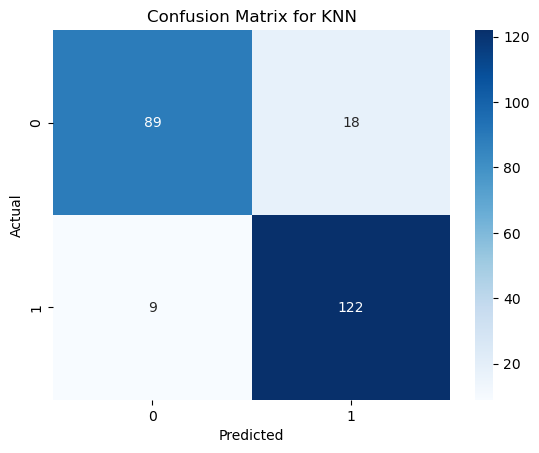

In [ ]:
acc_knn = accuracy_score(y_test, y_pred_knn) * 100
print("Accuracy=",acc_knn)
knn_cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
#SVM classifier

from sklearn.svm import SVC
svm = SVC(kernel='linear', random_state=42) # You can change the kernel (e.g., 'rbf', 'poly')
svm.fit(x_train, y_train)


SVC(kernel='linear', random_state=42)

In [ ]:
# Make predictions on the test set
y_pred_svm = svm.predict(x_test)


In [ ]:
# Evaluate the model
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.83      0.82      0.83       107
           1       0.86      0.86      0.86       131

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238



In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm) * 100
print("Accuracy=",acc_svm)


Accuracy= 84.45378151260505


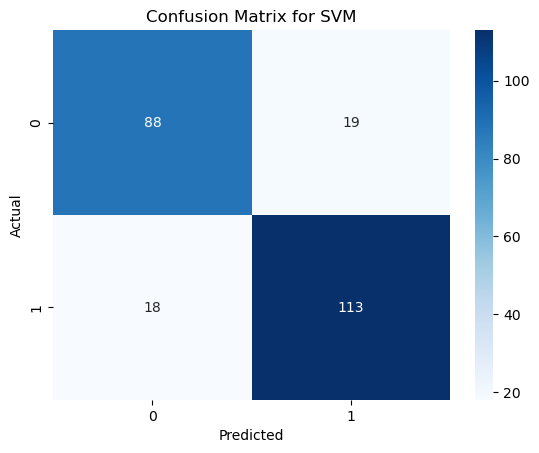

In [ ]:
svm_cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
model_accuracies = {
    'Naive Bayes': acc_gnb,
    'Logistic Regression': acc_lr,
    'Decision Tree': acc_dt,
    'KNN': acc_knn,
    'SVM': acc_svm
}


In [ ]:
best_model = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model]

print(f"The best performing model is {best_model} with an accuracy of {best_accuracy:.2f}%")


The best performing model is KNN with an accuracy of 88.66%


In [ ]:
model_data = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'KNN', 'SVM'],
    'Accuracy': [acc_gnb, acc_lr, acc_dt, acc_knn, acc_svm]
}


In [ ]:
model_comparison = pd.DataFrame(model_data)
model_comparison


,Model,Accuracy
0,Naive Bayes,85.714286
1,Logistic Regression,86.134454
2,Decision Tree,88.235294
3,KNN,88.655462
4,SVM,84.453782


(0.0, 100.0)

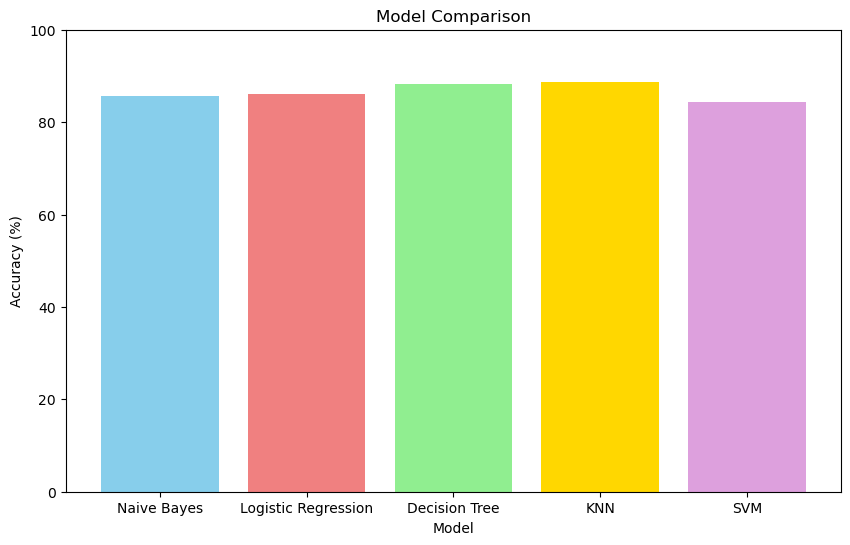

In [ ]:
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

plt.figure(figsize=(10, 6))
plt.bar(model_comparison['Model'],model_comparison['Accuracy'], color=colors)
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.ylim(0, 100) # Set y-axis limit to 100%
